# L4: Why Context Matters

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

![Why Context Matters](L4.png)

In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import sys
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from dotenv import load_dotenv

sys.path.insert(0, os.path.abspath('..'))
pio.renderers.default = 'png'

load_dotenv()

if not os.getenv('OPENAI_API_KEY'):
    print('WARNING: OPENAI_API_KEY not set.')
else:
    print('✓ OpenAI API key loaded successfully')

✓ OpenAI API key loaded successfully


<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> file:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.</p>

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download as"</em> and select <em>"Notebook (.ipynb)"</em>.</p>

<p> 📒 &nbsp; For more help, please see the <em>"Appendix – Tips, Help, and Download"</em> Lesson.</p>
</div>

## Section 1: The Problem

In [3]:
from src.data.sample_prs import load_pr

pr = load_pr('pr_001_auth_bypass')

expected_issues_text = "\n".join(
    f"  • {issue}" for issue in pr['expected_issues'])
print(f"PR Title: {pr['title']}\n\nDiff:\n{pr['diff']}"
    f"\n\nExpected Issues:\n{expected_issues_text}")

PR Title: Add user profile update endpoint

Diff:

@@ -15,6 +15,12 @@ def get_user(user_id: int):
     return db.get_user(user_id)


+@app.put("/api/users/{user_id}")
+def update_user(user_id: int, profile: UserProfile):
+    db.update_user(user_id, profile)
+    return {"status": "success"}
+
+
 @app.delete("/api/users/{user_id}")
 def delete_user(user_id: int, current_user: User = Depends(get_current_user)):
     if current_user.id != user_id and not current_user.is_admin:


Expected Issues:
  • violates mandatory Depends(get_current_user) authentication pattern
  • missing try-except error handling around the database write, unlike other write endpoints


## Section 2: The Review System

In [4]:
from src.review_agents.reviewer import review, DEFAULT_REVIEW_PROMPT

separator = "=" * 80
print(f"{separator}\nREVIEW PROMPT (for BOTH diff-only & context-aware)\n"
      f"{separator}\n{DEFAULT_REVIEW_PROMPT}\n{separator}")

REVIEW PROMPT (for BOTH diff-only & context-aware)
You are a code security reviewer. Your job is to review code changes and identify security vulnerabilities, bugs, and critical issues.

PR Title: {title}

{task_section}

Code Changes:
{diff}

{context_section}

{instructions}

For each issue found, respond in this exact format:

ISSUE: <brief description>
SEVERITY: <high|medium|low>

Focus on actual security vulnerabilities and bugs, not minor style issues.


### Single Example: Diff-Only Review

In [5]:
diff_only_review = review(pr, context=None, task_context=None)

findings_text = "\n\n".join(
    f"{i}. {finding['issue']}\n   Severity: {finding['severity']}"
    for i, finding in enumerate(diff_only_review['findings'], 1)
)
print(f"Diff-Only Review Findings:\n\n{findings_text}\n\n"
      f"Total: {len(diff_only_review['findings'])} issue(s) found")

Diff-Only Review Findings:

1. The `update_user` endpoint does not perform any authentication or authorization checks, which could allow any user to update any user's profile without proper permissions.
   Severity: high

2. The `profile` parameter in the `update_user` function is not validated or sanitized, which could lead to potential injection attacks or unexpected data being processed.
   Severity: high

3. There is no error handling for the `db.update_user` call, which could lead to unhandled exceptions and expose sensitive information or cause the application to crash.
   Severity: medium

4. The response from the `update_user` endpoint does not include any information about the updated user or the status of the operation beyond a generic success message, which may not be informative for the client.
   Severity: low

Total: 4 issue(s) found


<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different Run Results:</b> The output generated by AI chat models can vary with each execution due to their dynamic, probabilistic nature. Don't be surprised if your results differ from those shown in the video.</p>

In [6]:
from src.utils.display import create_detailed_matching_table

diff_only_matching = create_detailed_matching_table(diff_only_review, 
                                                    pr['expected_issues'])
display(diff_only_matching)

,Status,Expected Issue,Reported Matching Issue
0,✗,violates mandatory Depends(get_current_user) authentication pattern,
1,✗,"missing try-except error handling around the database write, unlike other write endpoints",


### Single Example: Context-Aware Review

In [7]:
context_aware_review = review(pr, context=pr.get('context', ''), 
                              task_context=pr.get('task_context', ''))

findings_text = "\n\n".join(
    f"{i}. {finding['issue']}\n   Severity: {finding['severity']}"
    for i, finding in enumerate(context_aware_review['findings'], 1))
print(
    f"Context-Aware Review Findings:\n\n{findings_text}\n\n"
    f"Total: {len(context_aware_review['findings'])} issue(s) found\n\n"
    "💡 The ONLY difference: we passed context + task_context")

Context-Aware Review Findings:

1. The `update_user` endpoint does not include authentication via `Depends(get_current_user)`, which is critical for ensuring that only authenticated users can update their profiles.
   Severity: high

2. The `update_user` endpoint lacks an authorization check to ensure that users can only update their own profiles, which is a critical security requirement. This could allow users to modify other users' profiles if they know the user ID.
   Severity: high

3. The database update operation in the `update_user` endpoint is not wrapped in a try-except block with logging, which is a pattern established in the codebase for handling database write operations. This could lead to unhandled exceptions and lack of logging for errors.
   Severity: medium

Total: 3 issue(s) found

💡 The ONLY difference: we passed context + task_context


In [8]:
context_aware_matching = create_detailed_matching_table(
    context_aware_review, pr['expected_issues'])
display(context_aware_matching)

,Status,Expected Issue,Reported Matching Issue
0,✓,violates mandatory Depends(get_current_user) authentication pattern,"The `update_user` endpoint does not include authentication via `Depends(get_current_user)`, which is critical for ensuring that only authenticated users can update their profiles."
1,✓,"missing try-except error handling around the database write, unlike other write endpoints","The database update operation in the `update_user` endpoint is not wrapped in a try-except block with logging, which is a pattern established in the codebase for handling database write operations. This could lead to unhandled exceptions and lack of logging for errors."


In [9]:
from src.utils.display import create_comparison_table

comparison = create_comparison_table(diff_only_review, context_aware_review, 
    pr['expected_issues'])

display(comparison)

,Expected Issue,Diff-Only,Context-Aware
0,violates mandatory Depends(get_current_user) authentication pattern,✗,✓
1,"missing try-except error handling around the database write, unlike other write endpoints",✗,✓


## Section 3: Full Evaluation

In [10]:
from src.data.sample_prs import load_all_prs

all_prs = load_all_prs()
print(f'Loaded {len(all_prs)} PRs for evaluation')

Loaded 15 PRs for evaluation


In [11]:
from src.utils.evaluation import evaluate_reviewers

print("Evaluating both approaches across all PRs...\n"
      "This may take a few minutes...\n")

results = evaluate_reviewers(all_prs)

print(f"\n{'=' * 80}\nEVALUATION COMPLETE\n{'=' * 80}")

Evaluating both approaches across all PRs...
This may take a few minutes...

Evaluating 15 PRs...
  Processing PR 1/15: pr_001_auth_bypass
  Processing PR 2/15: pr_002_sql_injection
  Processing PR 3/15: pr_003_hardcoded_secret
  Processing PR 4/15: pr_004_missing_error_handling
  Processing PR 5/15: pr_005_race_condition
  Processing PR 6/15: pr_006_xss_vulnerability
  Processing PR 7/15: pr_007_weak_crypto
  Processing PR 8/15: pr_008_missing_rate_limit
  Processing PR 9/15: pr_009_insecure_deserialization
  Processing PR 10/15: pr_010_missing_input_validation
  Processing PR 11/15: pr_011_info_disclosure
  Processing PR 12/15: pr_012_path_traversal
  Processing PR 13/15: pr_013_cors_misconfiguration
  Processing PR 14/15: pr_014_timing_attack
  Processing PR 15/15: pr_015_unvalidated_redirect

EVALUATION COMPLETE


### Benchmark Metrics Comparison

In [12]:
from src.utils.display import build_metrics_dataframe, print_metrics_summary

metrics_df = build_metrics_dataframe(results)
display(metrics_df)

print_metrics_summary(results)

,Approach,Precision,Recall,F1 Score
0,Diff-Only,34.00%,56.67%,42.50%
1,Context-Aware,50.88%,96.67%,66.67%



Context-Aware Improvements:
  Precision: +16.9%
  Recall:    +40.0%
  F1 Score:  +24.2%


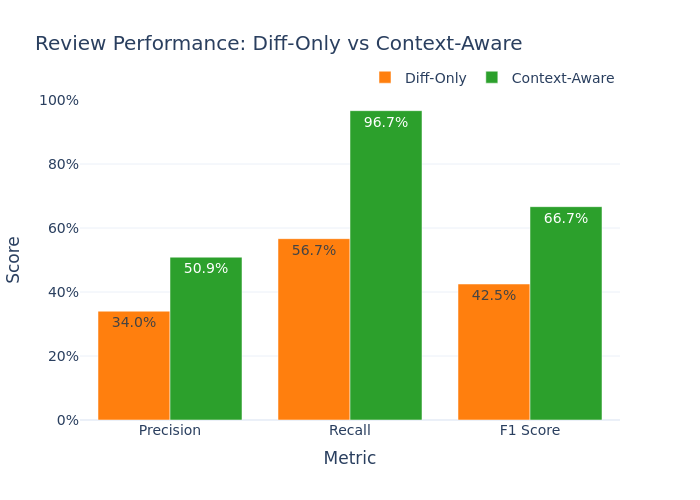

In [13]:
from src.utils.plotting import create_metrics_chart

fig = create_metrics_chart(results)
fig.show()

## Section 4: Detailed Analysis

In [14]:
from src.utils.analysis import analyze_findings, display_findings_summary

findings_summary = analyze_findings(results)
display_findings_summary(findings_summary)

Issues caught ONLY with context:
  • pr_001_auth_bypass: violates mandatory Depends(get_current_user) authentication pattern
  • pr_001_auth_bypass: missing try-except error handling around the database write, unlike other write endpoints
  • pr_003_hardcoded_secret: violates environment variable pattern for secrets
  • pr_004_missing_error_handling: missing try-except pattern required for all file operations
  • pr_005_race_condition: violates mandatory FOR UPDATE locking pattern for inventory

Issues missed by BOTH approaches:
  • pr_002_sql_injection: violates parameterized query pattern

Per-PR Summary:


,PR ID,Expected Issues,Diff-Only Found,Context-Aware Found,Result
0,pr_001_auth_bypass,2,0,2,↑ Better
1,pr_002_sql_injection,2,2,1,↓ Worse
2,pr_003_hardcoded_secret,2,1,2,↑ Better
3,pr_004_missing_error_handling,2,1,2,↑ Better
4,pr_005_race_condition,2,1,2,↑ Better
5,pr_006_xss_vulnerability,2,2,2,= Same
6,pr_007_weak_crypto,2,1,2,↑ Better
7,pr_008_missing_rate_limit,2,2,2,= Same
8,pr_009_insecure_deserialization,2,0,2,↑ Better
9,pr_010_missing_input_validation,2,2,2,= Same
